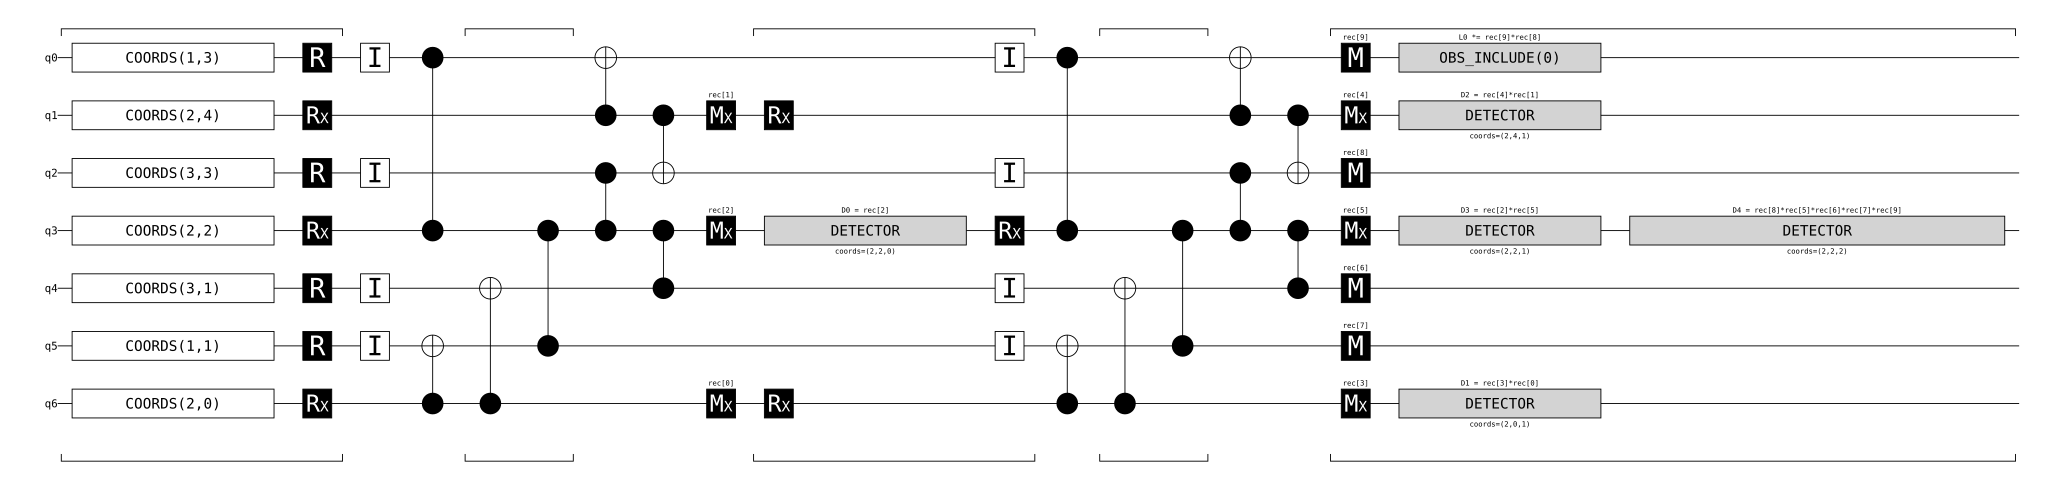

In [2]:
from deltakit_circuit import Coord2D
from deltakit_explorer.codes import css_code_memory_circuit, RepetitionCode, RotatedPlanarCode
from deltakit_circuit.gates import PauliBasis

from deltakit_explorer.codes import ScheduleOrder, ScheduleType
from deltakit_circuit import Coord2DDelta

d = 2
code = RotatedPlanarCode(
    width = d,
    height = d,
    top_bumps_are_z = False
)
# code.draw_patch()


circuit = css_code_memory_circuit(
    css_code=code,
    num_rounds=2,
    logical_basis=PauliBasis.Z,  # Z-basis stabilisers protect from bit flips
)
stim_circuit = circuit.as_stim_circuit()
# display(stim_circuit.diagram("timeslice-svg"))
stim_circuit.diagram("timeline-svg")

In [4]:
print(circuit.qubits)

frozenset({Qubit(Coord2D(1, 3)), Qubit(Coord2D(2, 4)), Qubit(Coord2D(3, 3)), Qubit(Coord2D(2, 2)), Qubit(Coord2D(3, 1)), Qubit(Coord2D(1, 1)), Qubit(Coord2D(2, 0))})


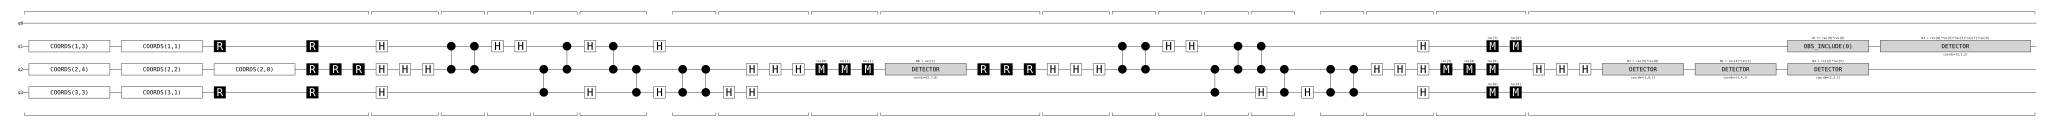

In [11]:
from deltakit_circuit import gates
from deltakit_decode.noise_sources import StimNoise
from deltakit_explorer.qpu import QPU, NativeGateSetAndTimes, ToyNoise, NoiseParameters

qpu_instance = QPU(
    qubits=circuit.qubits,  # only qubits we need are defined
    native_gates_and_times=NativeGateSetAndTimes(
        # times are given approximately for a superconducting device
        one_qubit_gates={gates.H: 20e-9, gates.SQRT_X: 20e-09},
        two_qubit_gates={gates.CZ: 30e-9},
        reset_gates={gates.RZ: 160e-9},
        measurement_gates={gates.MZ: 500e-9, gates.MRZ: 500e-9},
    ),
    # let's keep it noiseless for now, you may omit this line
    noise_model=NoiseParameters(),
)

deltakit_compiled_circuit = qpu_instance.compile_circuit(circuit)

# map qubit numbers with respect to their coordinates
mapping = {
    q: q.unique_identifier[0]
    for q in circuit.qubits
}

stim_circuit = deltakit_compiled_circuit.as_stim_circuit(mapping)

svg = stim_circuit.diagram("timeline-svg")
display(svg)
svg_string = str(svg)
with open(f"../scrap.svg", "w", encoding="utf-8") as f: f.write(svg_string)